In [1]:
import pandas as pd


In [78]:
caps= pd.read_excel("C:\\Users\\jtinoco2\\Downloads\\Failures-PMI\\Project-QM\\QM-CAPS.xlsx")
data = pd.read_excel("C:\\Users\\jtinoco2\\Downloads\\Failures-PMI\\Project-QM\\data.xlsx")

In [11]:
caps.head()

,BU,Cell,IMDL,Employee,Competency,Current,Role,Target,Dec,Ene,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep
0,FILTERS,FM_Caps,1000693778,Landin Atxel,AM Overview,1,Equipment Owner Secondary - Phase 1,2,1,2,2,2,2,2,2,2,2,2
1,FILTERS,FM_Caps,1000693778,Landin Atxel,AM step 1,1,Equipment Owner Secondary - Phase 1,3,1,1,1,2,2,2,2,2,2,2
2,FILTERS,FM_Caps,1000661057,Mejia Leonardo,AM step 1,1,Equipment Owner Secondary - Phase 1,3,1,1,1,2,2,2,2,2,2,2
3,FILTERS,FM_Caps,1000784502,Pellegrini Oscar,AM step 1,1,Process Lead - Phase 1,3,1,1,2,3,3,3,3,3,3,3
4,FILTERS,FM_Caps,1000693778,Landin Atxel,AM step 2,1,Equipment Owner Secondary - Phase 1,3,1,1,1,2,2,2,2,2,2,2


In [57]:
caps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   BU          1020 non-null   object
 1   Cell        1020 non-null   object
 2   IMDL        1020 non-null   int64 
 3   Employee    1020 non-null   object
 4   Competency  1020 non-null   object
 5   Current     1020 non-null   int64 
 6   Role        1020 non-null   object
 7   Target      1020 non-null   int64 
 8   Dec         1020 non-null   int64 
 9   Ene         1020 non-null   int64 
 10  Feb         1020 non-null   int64 
 11  Mar         1020 non-null   int64 
 12  Abr         1020 non-null   int64 
 13  May         1020 non-null   int64 
 14  Jun         1020 non-null   int64 
 15  Jul         1020 non-null   int64 
 16  Ago         1020 non-null   int64 
 17  Sep         1020 non-null   int64 
dtypes: int64(13), object(5)
memory usage: 143.6+ KB


In [13]:
data.head()

,Employee,Competency,Current,Target
0,Zuniga Victor,AM step 1,2,3
1,Zuniga Victor,AM step 2,2,3
2,Zuniga Victor,AM step 3,2,3
3,Zuniga Victor,BDE,2,3
4,Zuniga Victor,FPQ,2,3


In [56]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445 entries, 0 to 444
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Employee    445 non-null    object
 1   Competency  445 non-null    object
 2   Current     445 non-null    int64 
 3   Target      445 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 14.0+ KB


In [79]:
# Normalizar nombres de columnas en ambos archivos
data.columns = data.columns.str.strip()
caps.columns = caps.columns.str.strip()


In [80]:

month_cols = ["Dec", "Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep"]
existing_month_cols = [col for col in month_cols if col in caps.columns]
print("Columnas detectadas de meses:", existing_month_cols)

Columnas detectadas de meses: ['Dec', 'Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep']


In [81]:
caps_relevant = caps[["Employee", "Competency", "Current", "Target"] + existing_month_cols]

In [82]:
merged = caps.merge(
    data.rename(columns={"Current": "Current_data", "Target": "Target_data"}),
    on=["Employee", "Competency"],
    how="left",
    indicator=True
)

# Etiqueta de coincidencia
merged["Match_Status"] = merged.apply(
    lambda r: "Coincide" 
              if (r["Current"] == r["Current_data"]) and (r["Target"] == r["Target_data"])
              else "No coincide",
    axis=1
)


In [83]:
merged["Current"] = merged.apply(
    lambda r: r["Current_data"] if pd.notna(r["Current_data"]) else r["Current"],
    axis=1
)

merged["Target"] = merged.apply(
    lambda r: r["Target_data"] if pd.notna(r["Target_data"]) else r["Target"],
    axis=1
)

In [84]:
def detectar_cambio_y_valores(row):
    for i in range(1, len(existing_month_cols)):
        prev_val = row[existing_month_cols[i-1]]
        curr_val = row[existing_month_cols[i]]
        if curr_val > prev_val:
            return pd.Series({
                "First_Change_Month": existing_month_cols[i],
                "Change_From": prev_val,
                "Change_To": curr_val
            })
    return pd.Series({
        "First_Change_Month": None,
        "Change_From": None,
        "Change_To": None
    })

merged[["First_Change_Month", "Change_From", "Change_To"]] = merged.apply(
    detectar_cambio_y_valores, axis=1
)

In [85]:
merged["First_Change_Month"].head(20)

0      Ene
1      Mar
2      Mar
3      Feb
4      Mar
5      Mar
6      Mar
7      Mar
8      Mar
9      Mar
10     Mar
11     Mar
12     Mar
13     Mar
14     Feb
15     Ene
16     Feb
17     Feb
18    None
19    None
Name: First_Change_Month, dtype: object

In [86]:
def clasificar_prioridad(mes):
    if mes in ["Ene", "Feb", "Mar"]:
        return "Prioridad"
    elif mes in ["Abr", "May", "Jun", "Jul"]:
        return "Próximos meses"
    elif mes in ["Ago", "Sep"]:
        return "Final de año"
    else:
        return "Sin cambio programado"

merged["Priority_Level"] = merged["First_Change_Month"].apply(clasificar_prioridad)

In [87]:
resultado = merged[[
    "Employee", "Competency", "Current", "Target",
    "First_Change_Month", "Change_From", "Change_To",
    "Priority_Level", "Match_Status"
]]

In [88]:
resultado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Employee            1020 non-null   object 
 1   Competency          1020 non-null   object 
 2   Current             1020 non-null   float64
 3   Target              1020 non-null   float64
 4   First_Change_Month  278 non-null    object 
 5   Change_From         278 non-null    float64
 6   Change_To           278 non-null    float64
 7   Priority_Level      1020 non-null   object 
 8   Match_Status        1020 non-null   object 
dtypes: float64(4), object(5)
memory usage: 71.8+ KB


In [73]:
resultado.head()

,Employee,Competency,Current,Target,First_Change_Month,Change_From,Change_To,Priority_Level,Match_Status
0,Landin Atxel,AM Overview,1.0,2.0,Ene,1.0,2.0,Sin cambio programado,Coincide
1,Landin Atxel,AM step 1,1.0,3.0,Mar,1.0,2.0,Prioridad,Coincide
2,Mejia Leonardo,AM step 1,2.0,3.0,Mar,1.0,2.0,Prioridad,No coincide
3,Pellegrini Oscar,AM step 1,1.0,3.0,Feb,1.0,2.0,Prioridad,Coincide
4,Landin Atxel,AM step 2,1.0,3.0,Mar,1.0,2.0,Prioridad,Coincide


### Arreglar incomformidad de no coincide :

In [90]:
resultado.to_excel("QM_Analisis.xlsx", index=False)

In [89]:

resultado = resultado[resultado["Current"] != resultado["Target"]]      # Quitar casos sin brecha
resultado = resultado[resultado["Current"] <= resultado["Target"]]      # Quitar inconsistencias
resultado = resultado.reset_index(drop=True)


In [91]:
resultado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 436 entries, 0 to 435
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Employee            436 non-null    object 
 1   Competency          436 non-null    object 
 2   Current             436 non-null    float64
 3   Target              436 non-null    float64
 4   First_Change_Month  278 non-null    object 
 5   Change_From         278 non-null    float64
 6   Change_To           278 non-null    float64
 7   Priority_Level      436 non-null    object 
 8   Match_Status        436 non-null    object 
dtypes: float64(4), object(5)
memory usage: 30.8+ KB


## Visualizaciones

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict
from datetime import datetime
import os

# -----------------------------
# 1) CARGA DE DATOS
# -----------------------------
df = pd.read_excel("QM_Analisis.xlsx", engine="openpyxl")

# Normalizar columnas
df.columns = df.columns.str.strip()
for c in ['First_Change_Month','Priority_Level','Match_Status','Employee','Competency']:
    df[c] = df[c].astype(str).str.strip()

# Orden de meses (Ene–Sep)
mes_order = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep"]
df['First_Change_Month'] = pd.Categorical(df['First_Change_Month'], categories=mes_order, ordered=True)

# -----------------------------
# 2) KPIs BÁSICOS
# -----------------------------
kpis = OrderedDict()
kpis['Total registros'] = len(df)
kpis['Urgentes (Feb/Mar)'] = (df['Priority_Level'] == 'Prioridad').sum()
kpis['Próximos meses (Abr–Jul)'] = (df['Priority_Level'] == 'Próximos meses').sum()
kpis['Final de año (Ago–Sep)'] = (df['Priority_Level'] == 'Final de año').sum()
kpis['Sin cambio programado'] = (df['Priority_Level'] == 'Sin cambio programado').sum()
kpis['% No coincide'] = round(100 * (df['Match_Status'] == 'No coincide').mean(), 1)

kpis


OrderedDict([('Total registros', 410),
             ('Urgentes (Feb/Mar)', np.int64(172)),
             ('Próximos meses (Abr–Jul)', np.int64(76)),
             ('Final de año (Ago–Sep)', np.int64(10)),
             ('Sin cambio programado', np.int64(152)),
             ('% No coincide', np.float64(14.1))])

In [93]:
# Filtrado para análisis de cambios con mes definido
df_mes = df[df['First_Change_Month'].notna()].copy()

# Vistas por prioridad
df_urgente = df[df['Priority_Level'] == 'Prioridad'].copy()           # Ene/Feb/Mar
df_prox    = df[df['Priority_Level'] == 'Próximos meses'].copy()      # Abr–Jul
df_fin     = df[df['Priority_Level'] == 'Final de año'].copy()        # Ago–Sep
df_sin     = df[df['Priority_Level'] == 'Sin cambio programado'].copy()

In [94]:
plt.style.use('seaborn-v0_8-whitegrid')  # estilo limpio
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

def savefig(fname):
    os.makedirs("figs", exist_ok=True)
    plt.tight_layout()
    plt.savefig(os.path.join("figs", fname), dpi=160, bbox_inches='tight')
    plt.show()


C:\Users\jtinoco2\AppData\Local\Temp\ipykernel_25308\2730764372.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conteo_mes = (df_mes.groupby('First_Change_Month')


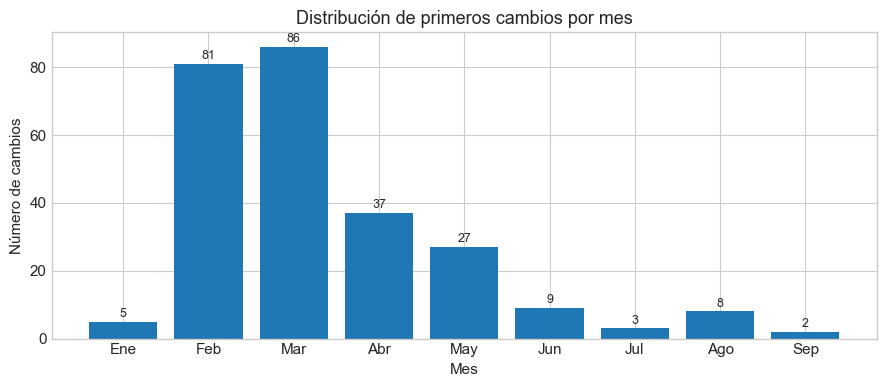

In [95]:
fig, ax = plt.subplots(figsize=(9,4))
conteo_mes = (df_mes.groupby('First_Change_Month')
                    .size()
                    .reindex(mes_order)
                    .fillna(0)
                    .astype(int))
ax.bar(conteo_mes.index.astype(str), conteo_mes.values, color="#1f77b4")
ax.set_title("Distribución de primeros cambios por mes")
ax.set_xlabel("Mes")
ax.set_ylabel("Número de cambios")
for x, v in enumerate(conteo_mes.values):
    ax.text(x, v+0.5, str(v), ha='center', va='bottom', fontsize=9)
savefig("01_cambios_por_mes.png")

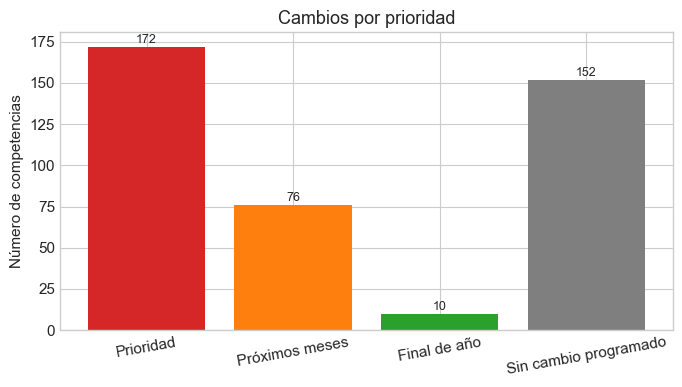

In [96]:
fig, ax = plt.subplots(figsize=(7,4))
conteo_prio = (df['Priority_Level']
               .value_counts()
               .reindex(["Prioridad","Próximos meses","Final de año","Sin cambio programado"])
               .fillna(0)
               .astype(int))
ax.bar(conteo_prio.index, conteo_prio.values, color=["#d62728","#ff7f0e","#2ca02c","#7f7f7f"])
ax.set_title("Cambios por prioridad")
ax.set_ylabel("Número de competencias")
for x, v in enumerate(conteo_prio.values):
    ax.text(x, v+0.5, str(v), ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=10)
savefig("02_cambios_por_prioridad.png")

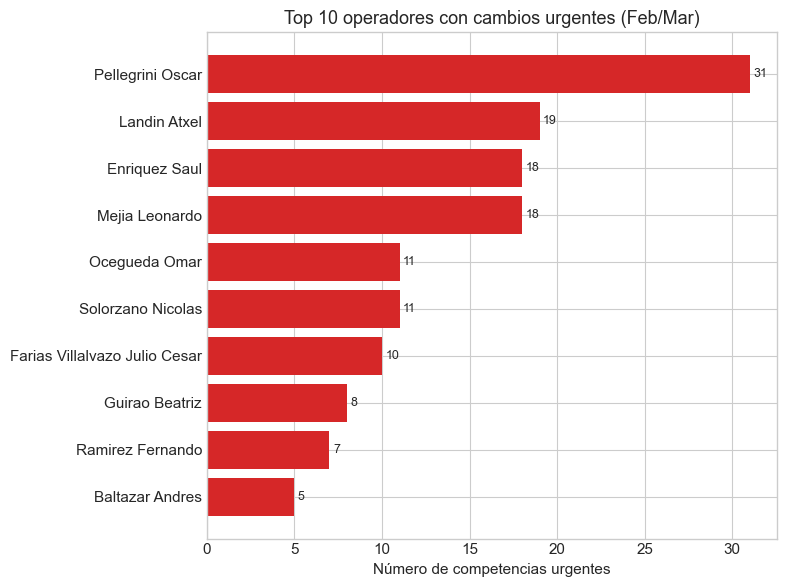

In [97]:
fig, ax = plt.subplots(figsize=(8,6))
top_emp_urg = (df_urgente.groupby('Employee').size()
               .sort_values(ascending=False).head(10))
ax.barh(top_emp_urg.index[::-1], top_emp_urg.values[::-1], color="#d62728")
ax.set_title("Top 10 operadores con cambios urgentes (Feb/Mar)")
ax.set_xlabel("Número de competencias urgentes")
for i, v in enumerate(top_emp_urg.values[::-1]):
    ax.text(v+0.2, i, str(v), va='center', fontsize=9)
savefig("03_top10_operadores_urgentes.png")

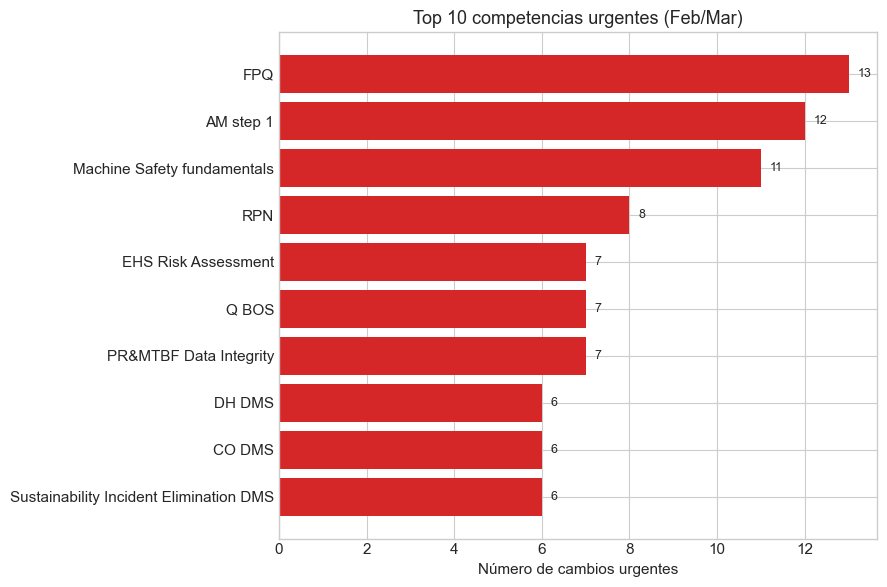

In [98]:
fig, ax = plt.subplots(figsize=(9,6))
top_comp_urg = (df_urgente.groupby('Competency').size()
                .sort_values(ascending=False).head(10))
ax.barh(top_comp_urg.index[::-1], top_comp_urg.values[::-1], color="#d62728")
ax.set_title("Top 10 competencias urgentes (Feb/Mar)")
ax.set_xlabel("Número de cambios urgentes")
for i, v in enumerate(top_comp_urg.values[::-1]):
    ax.text(v+0.2, i, str(v), va='center', fontsize=9)
savefig("04_top10_competencias_urgentes.png")


C:\Users\jtinoco2\AppData\Local\Temp\ipykernel_25308\3050472045.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  matrix = (df_mes.groupby(['Employee','First_Change_Month'])


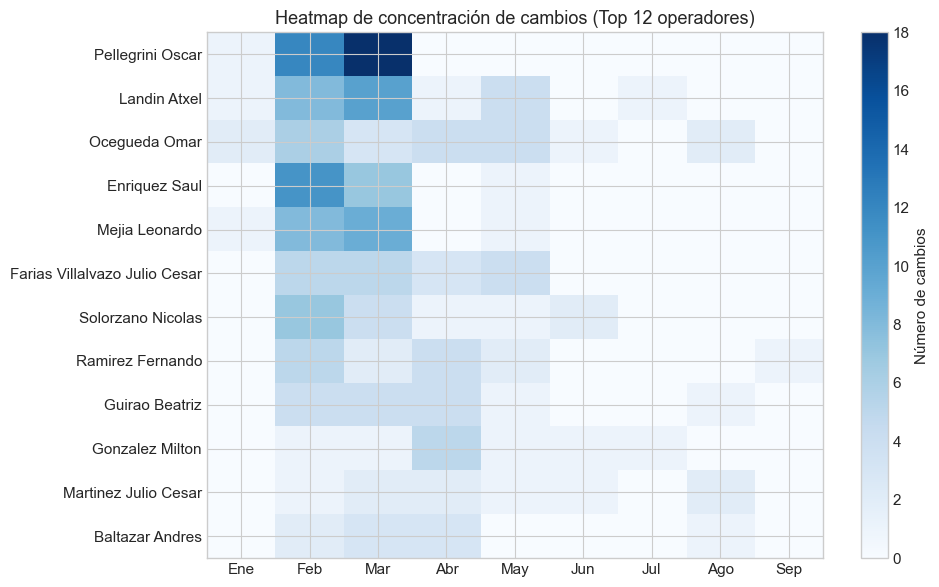

In [100]:
# Matriz empleado vs mes (para los que sí tienen mes de cambio)
matrix = (df_mes.groupby(['Employee','First_Change_Month'])
               .size().unstack(fill_value=0)
               .reindex(columns=mes_order))

top_empleados = matrix.sum(axis=1).sort_values(ascending=False).head(12).index
mat = matrix.loc[top_empleados]

fig, ax = plt.subplots(figsize=(10,6))
im = ax.imshow(mat.values, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(mat.columns)))
ax.set_xticklabels(mat.columns)
ax.set_yticks(range(len(mat.index)))
ax.set_yticklabels(mat.index)
ax.set_title("Heatmap de concentración de cambios (Top 12 operadores)")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Número de cambios')
savefig("05_heatmap_operador_mes.png")
